# Chapter9 gover 搜索算法

## 9.1 量子相位反冲

手动制作，两个比特都是 $\pi$ 相位。

**图上颜色可以看出是正常的相对相位相位。** 这个破书的理解是 $|1\rangle$ 转 $\pi$ 相位所以 $|11\rangle$ 是 $2\pi$ 不变，也对。

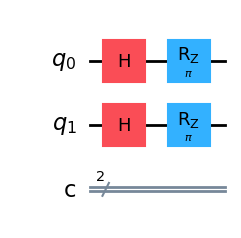

Statevector([-0.5-6.123234e-17j,  0.5+0.000000e+00j,  0.5+0.000000e+00j,
             -0.5+6.123234e-17j],
            dims=(2, 2))


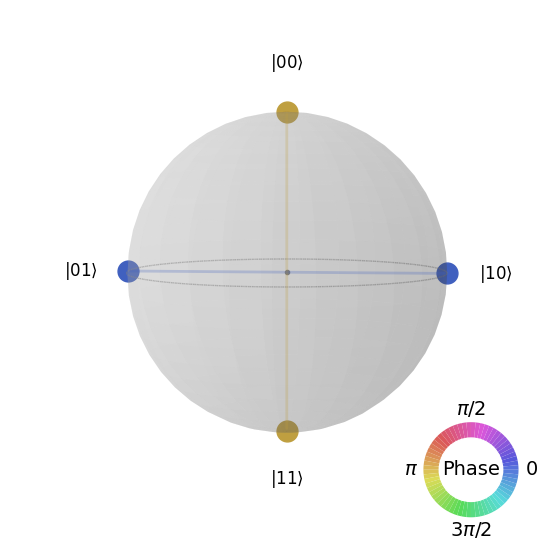

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_state_qsphere
# circ
circ = QuantumCircuit(2, 2)
circ.h([0, 1])
circ.rz([0, 1])
display(circ.draw('mpl'))
# qsphere plot
circ.save_statevector()
vec_backend = Aer.get_backend('aer_simulator_statevector')
vec_result = vec_backend.run(circ).result()
psi = vec_result.get_statevector()
print(psi)
display(plot_state_qsphere(psi))

相位为pi，作为受控受控位置，可以反控制。

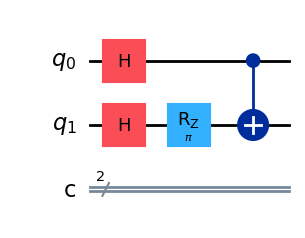

Statevector([3.061617e-17-0.5j, 3.061617e-17+0.5j, 3.061617e-17+0.5j,
             3.061617e-17-0.5j],
            dims=(2, 2))


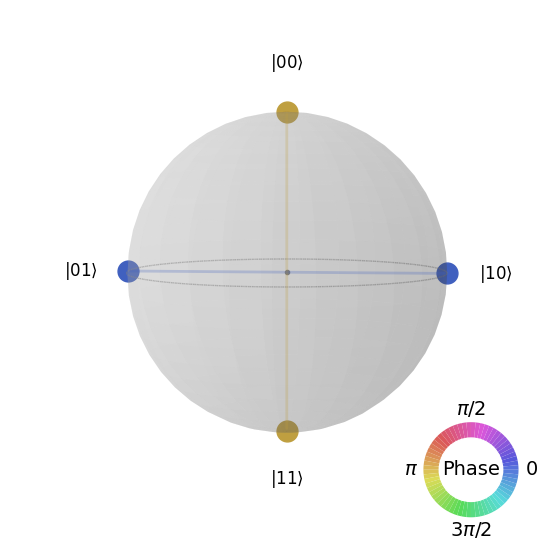

In [12]:
circ = QuantumCircuit(2, 2)
circ.h([0, 1])
circ.rz(np.pi, 1)
circ.cx(0, 1)
display(circ.draw('mpl'))

# qsphere plot
circ.save_statevector()
vec_backend = Aer.get_backend('aer_simulator_statevector')
vec_result = vec_backend.run(circ).result()
psi = vec_result.get_statevector()
print(psi)
display(plot_state_qsphere(psi))

## 9.2 双比特grover

我想不到有什么意义，可能需要绑定其他信息？

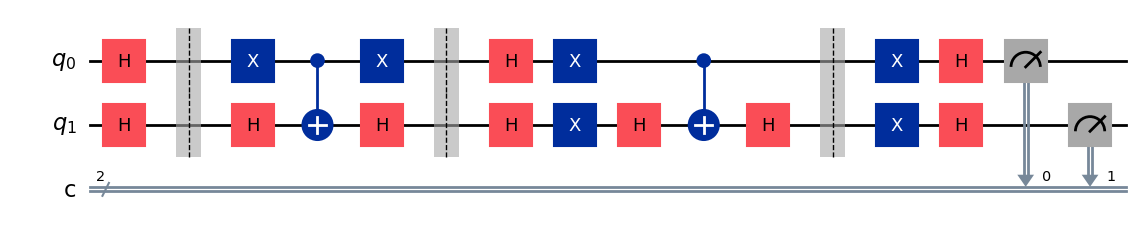

In [4]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_state_qsphere

# 均匀初态
circ = QuantumCircuit(2, 2)
circ.h([0, 1])
circ.barrier([0, 1])
# |01\rangle 取反
circ.x(0)
circ.h(1)
circ.cx(0, 1)
circ.x(0)
circ.h(1)
circ.barrier([0, 1])
# 放大反位
circ.h([0, 1])
circ.x([0, 1])
circ.h(1)
circ.cx(0, 1)
circ.h(1)
circ.barrier([0, 1])
circ.x([0, 1])
circ.h([0, 1])
circ.measure([0, 1], [0, 1])
display(circ.draw('mpl'))


In [13]:
import os
import time
import matplotlib.pyplot as plt 
from qiskit import QuantumCircuit, qasm2
from quark import Task

def quark_comp(qiskit_circ, repeat_count=1, my_job='my_job', chip='Baihua', target_qubits=[]):
    # circ trans
    qasm_circ = qasm2.dumps(qiskit_circ)
    # tmgr
    token = os.getenv('QUARK_API_TOKEN')
    tmgr = Task(token) # task manager
    task = {
    'chip': chip,  
    'name': my_job,  
    'circuit':qasm_circ, # circuit written in OpenQASM2.0
    'compile': True, # 可能用模拟机。(你要是自信自己写的全是基础门就用False.)
    'options':{
        'correct': False,
        'target_qubits': target_qubits # 具体bit而非范围。 
    }
    }

    tid = tmgr.run(task, repeat=repeat_count) # shots = repeat*1024
    res = tmgr.result(tid)
    while not res:
        time.sleep(1)
        res = tmgr.result(tid)
    display(res)

    data = res['count']
    bases = sorted(data) # 00, 01, 10, 11
    count = [data[base] for base in bases]
    plt.bar(bases, count)
    plt.xticks(rotation=45)
    return data

{'count': {'10': 843, '00': 90, '11': 76, '01': 15},
 'corrected': {},
 'chip': 'Yudu',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[0];\nh q[1];\nbarrier q[0],q[1];\nx q[0];\nh q[1];\ncx q[0],q[1];\nx q[0];\nh q[1];\nbarrier q[0],q[1];\nh q[0];\nh q[1];\nx q[0];\nx q[1];\nh q[1];\ncx q[0],q[1];\nh q[1];\nbarrier q[0],q[1];\nx q[0];\nx q[1];\nh q[0];\nh q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];',
 'transpiled': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[43];\ncreg c[2];\nh q[36];\nh q[42];\nbarrier q[36],q[42];\nx q[36];\nh q[42];\ncx q[36],q[42];\nx q[36];\nh q[42];\nbarrier q[36],q[42];\nh q[36];\nh q[42];\nx q[36];\nx q[42];\nh q[42];\ncx q[36],q[42];\nh q[42];\nbarrier q[36],q[42];\nx q[36];\nx q[42];\nh q[36];\nh q[42];\nbarrier q[36],q[42];\nmeasure q[36] -> c[0];\nmeasure q[42] -> c[1];',
 'qlisp': "[(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q36'),\n(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q42'),\n('Barrier', 

{'10': 843, '00': 90, '11': 76, '01': 15}

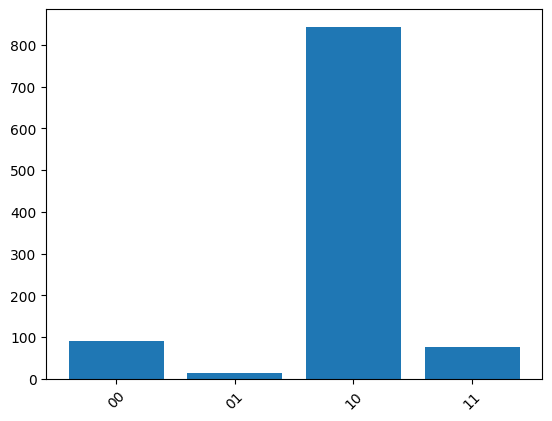

In [7]:
quark_comp(circ)

## 9.3 多比特grover

也没说原理直接用包装好的。需要现构造oracle，根据其制备有初态的电路：

* 'x & y' - 逻辑与（AND）
* 'x | y' - 逻辑或（OR）
* '~x' - 逻辑非（NOT）

Q是"Quantum Oracle"的缩写，表示这是一个量子黑盒操作。oracle意味预言机。

太逆天了。

In [62]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, PhaseOracle

# 1. 创建预言机 (例如：搜索 |......> 状态)
oracle = PhaseOracle('~a & b & c & d & e')  # oracle 本身就是一个 QuantumCircuit 对象

# 初态
n_qubits = oracle.num_qubits
state_preparation = QuantumCircuit(n_qubits)
state_preparation.h(range(n_qubits))  # 创建均匀叠加态

# 3. 生成 Grover 算子电路
grover_op = grover_operator(
    oracle=oracle,
    state_preparation=state_preparation
)

# 4. 构建完整 Grover 电路 (1次迭代), 每次迭代都会使目标状态的概率振幅增加，非目标状态的振幅减少。
iterations = 100
grover_circuit = QuantumCircuit(n_qubits)
grover_circuit.compose(state_preparation, inplace=True)  # 初始叠加
grover_circuit.compose(grover_op.power(iterations), inplace=True)  # 应用 Grover 算子

# 5. 添加测量 (如果需要)
grover_circuit.measure_all()


/tmp/ipykernel_7729/437522120.py:5: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle('~a & b & c & d & e')  # oracle 本身就是一个 QuantumCircuit 对象


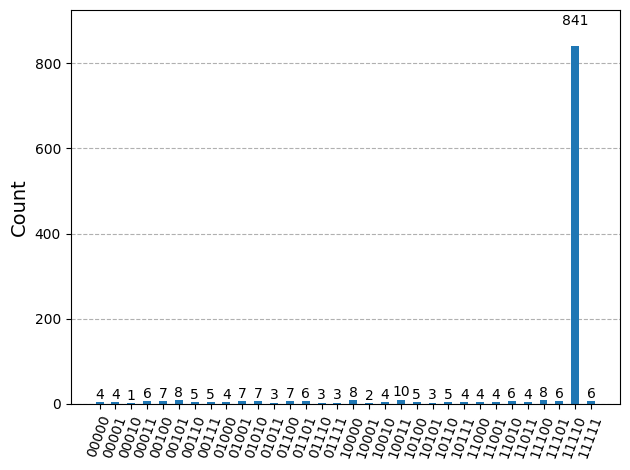

In [63]:
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram

backend = Aer.get_backend('aer_simulator') 
transpiled_circ = transpile(grover_circuit, backend) 
job = backend.run(transpiled_circ, shots=1000) 
result = job.result() 
counts = result.get_counts()
plot_histogram(counts)

无法接受Q了。。。

In [59]:
quark_comp(grover_circuit)

{'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\ngate ccz q0,q1,q2 { h q2; ccx q0,q1,q2; h q2; }\ngate ccz_o2 q0,q1,q2 { x q0; ccz q0,q1,q2; x q0; }\ngate gate_Q q0,q1,q2 { ccz_o2 q0,q1,q2; h q2; h q1; h q0; x q0; x q1; x q2; h q2; ccx q0,q1,q2; h q2; x q0; x q1; x q2; h q0; h q1; h q2; }\nqreg q[3];\ncreg meas[3];\nh q[0];\nh q[1];\nh q[2];\ngate_Q q[0],q[1],q[2];\nbarrier q[0],q[1],q[2];\nmeasure q[0] -> meas[0];\nmeasure q[1] -> meas[1];\nmeasure q[2] -> meas[2];',
 'error': '[2601051945415140964]Failed to transpile: Sorry, an unrecognized OpenQASM 2.0 syntax gate_Q was detected by quarkcircuit. Please contact the developer for assistance.'}

KeyError: 'count'